# EDA v2 — Feature Set Redesign

**Goal**: answer what EDA.ipynb didn't — do the proposed new features carry *regime-conditional* signal?

Questions this notebook answers:
1. Are `bb_width` and `macd_hist` actually redundant with `vol_20d` and `rsi_14`?
2. Do the four new features (`sma_200_dist`, `drawdown_60d`, `vol_regime`, `ret_20d`) have higher IC in bear regimes?
3. Which features best *predict* a drawdown day (SPY < −1%)?

**Not re-done here**: OHLCV overview, stationarity/normality tests, ACF/PACF, per-indicator dashboards — those are in EDA.ipynb.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ta
from scipy import stats

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
})

## 1 — Load & Compute All Features (Old + New)

In [2]:
df = pd.read_csv('../data/raw/SPY.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Raw: {df.shape}  |  {df.date.min().date()} → {df.date.max().date()}')

# ── Features being KEPT ──────────────────────────────────────────────────────
df['ret_1d']   = df['close'].pct_change(1)
df['ret_5d']   = df['close'].pct_change(5)
sma20          = df['close'].rolling(20).mean()
df['sma_ratio']= df['close'] / sma20
df['vol_20d']  = df['ret_1d'].rolling(20).std()
df['vol_ratio']= df['volume'] / df['volume'].rolling(20).mean()
df['rsi_14']   = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

adx_ind          = ta.trend.ADXIndicator(high=df['high'], low=df['low'], close=df['close'], window=14)
df['adx']        = adx_ind.adx()
df['adx_di_diff']= (adx_ind.adx_pos() - adx_ind.adx_neg()) / 100.0

obv = ta.volume.OnBalanceVolumeIndicator(close=df['close'], volume=df['volume']).on_balance_volume()
df['obv_ret'] = obv.pct_change(1).replace([np.inf, -np.inf], np.nan)

# ── Features being DROPPED (keep to prove redundancy) ────────────────────────
macd = ta.trend.MACD(close=df['close'], window_slow=26, window_fast=12, window_sign=9)
df['macd_hist']= macd.macd_diff() / df['close']

bb = ta.volatility.BollingerBands(close=df['close'], window=20, window_dev=2)
df['bb_width'] = bb.bollinger_wband()

# ── NEW features ─────────────────────────────────────────────────────────────
sma200           = df['close'].rolling(200).mean()
df['sma_200_dist']= df['close'] / sma200 - 1          # long-horizon regime: + = above MA

df['drawdown_60d']= df['close'] / df['close'].rolling(60).max() - 1   # <=0, how far from 60d peak

vol_60d           = df['ret_1d'].rolling(60).std()
df['vol_regime']  = df['vol_20d'] / vol_60d            # >1 = vol expanding, <1 = contracting

df['ret_20d']     = df['close'].pct_change(20)

# ── Target: next-day return ───────────────────────────────────────────────────
df['ret_next'] = df['ret_1d'].shift(-1)

df = df.dropna().reset_index(drop=True)
print(f'After dropna: {df.shape}')

KEEP_FEATURES = ['ret_1d','ret_5d','sma_ratio','vol_20d','vol_ratio',
                 'rsi_14','adx','adx_di_diff','obv_ret']
DROP_FEATURES = ['bb_width','macd_hist']
NEW_FEATURES  = ['sma_200_dist','drawdown_60d','vol_regime','ret_20d']
ALL_FEATURES  = KEEP_FEATURES + DROP_FEATURES + NEW_FEATURES

Raw: (4023, 8)  |  2010-01-04 → 2025-12-30
After dropna: (3823, 24)


## 2 — Regime Labeling

Three regimes defined by SMA-200:  
- **Bull**: close > SMA-200  
- **Bear**: close < SMA-200  
- **Transition**: within ±1% of SMA-200 (edge case, small)

Known bear periods annotated for visual reference.

Regime distribution:
regime
bull    3321
bear     502
Name: count, dtype: int64
Bear fraction: 13.1%


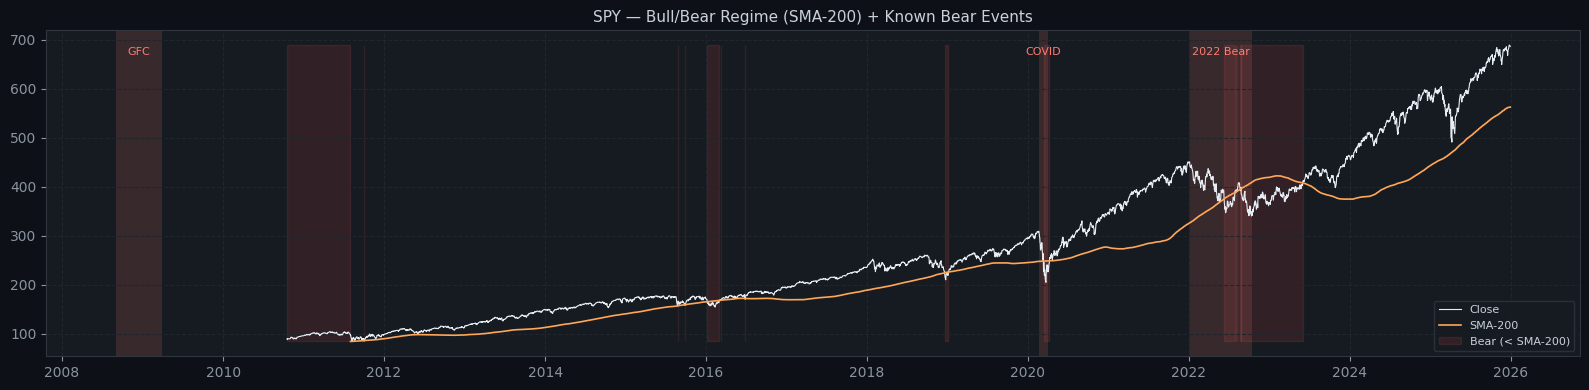

In [3]:
df['regime'] = np.where(df['close'] > sma200.loc[df.index], 'bull', 'bear')

regime_counts = df['regime'].value_counts()
print('Regime distribution:')
print(regime_counts)
print(f'Bear fraction: {(df.regime=="bear").mean()*100:.1f}%')

# Known bear regimes for annotation
bear_periods = [
    ('2008-09-01', '2009-03-31', 'GFC'),
    ('2020-02-20', '2020-04-01', 'COVID'),
    ('2022-01-01', '2022-10-15', '2022 Bear'),
]

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df['date'], df['close'], color='#e6edf3', lw=0.8, label='Close')
ax.plot(df['date'], sma200.loc[df.index].values, color='#ffa657', lw=1.2, label='SMA-200')

# Shade bear regime
bear_mask = df['regime'] == 'bear'
ax.fill_between(df['date'], df['close'].min(), df['close'].max(),
                where=bear_mask, color='#f85149', alpha=0.12, label='Bear (< SMA-200)')

for start, end, label in bear_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color='#ff7b72', alpha=0.15, lw=0)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, df['close'].max() * 0.97, label,
            ha='center', fontsize=8, color='#ff7b72')

ax.set_title('SPY — Bull/Bear Regime (SMA-200) + Known Bear Events', fontsize=11)
ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

## 3 — Drop Justification: Redundancy Check

`bb_width` ≈ `vol_20d`: both measure realized short-term volatility.  
`macd_hist` ≈ `rsi_14`: both measure momentum exhaustion.

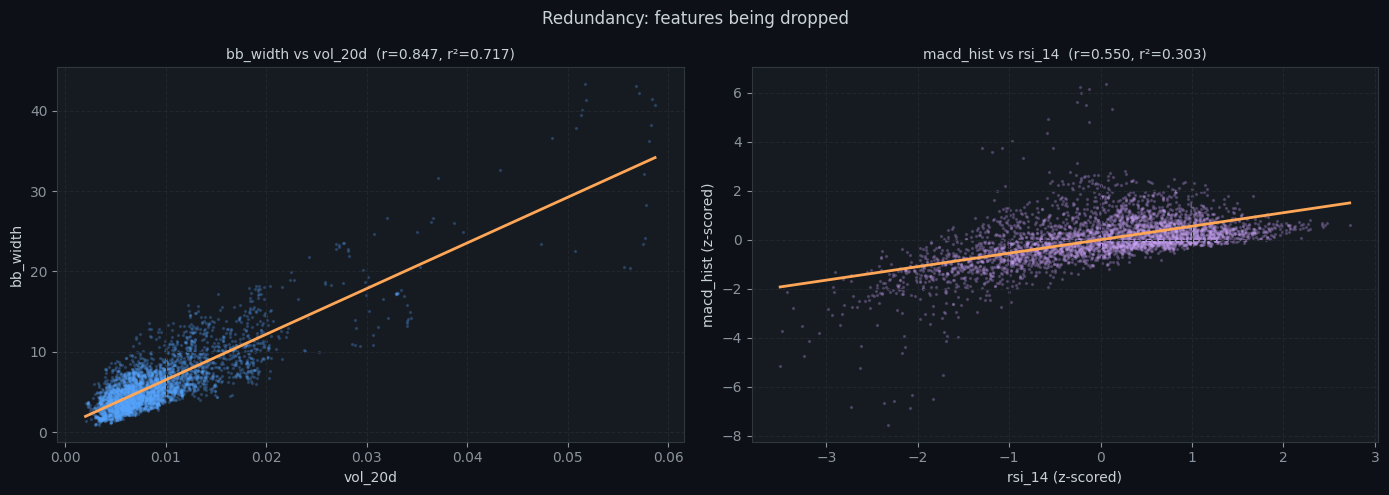

bb_width explains 71.7% of vol_20d variance → dropping bb_width
macd_hist explains 30.3% of rsi_14 variance → dropping macd_hist


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bb_width vs vol_20d
r1, p1 = stats.pearsonr(df['bb_width'].dropna(), df['vol_20d'].loc[df['bb_width'].dropna().index])
axes[0].scatter(df['vol_20d'], df['bb_width'], s=2, alpha=0.2, color='#58a6ff')
m, b = np.polyfit(df['vol_20d'].dropna(), df['bb_width'].loc[df['vol_20d'].dropna().index], 1)
x = np.linspace(df['vol_20d'].min(), df['vol_20d'].max(), 100)
axes[0].plot(x, m*x+b, color='#ffa657', lw=2)
axes[0].set_xlabel('vol_20d'); axes[0].set_ylabel('bb_width')
axes[0].set_title(f'bb_width vs vol_20d  (r={r1:.3f}, r²={r1**2:.3f})', fontsize=10)
axes[0].grid(True)

# macd_hist vs rsi_14 — both z-scored first so they're on same scale
macd_z = (df['macd_hist'] - df['macd_hist'].mean()) / df['macd_hist'].std()
rsi_z  = (df['rsi_14']   - df['rsi_14'].mean())    / df['rsi_14'].std()
r2, p2 = stats.pearsonr(macd_z, rsi_z)
axes[1].scatter(rsi_z, macd_z, s=2, alpha=0.2, color='#d2a8ff')
m2, b2 = np.polyfit(rsi_z, macd_z, 1)
x2 = np.linspace(rsi_z.min(), rsi_z.max(), 100)
axes[1].plot(x2, m2*x2+b2, color='#ffa657', lw=2)
axes[1].set_xlabel('rsi_14 (z-scored)'); axes[1].set_ylabel('macd_hist (z-scored)')
axes[1].set_title(f'macd_hist vs rsi_14  (r={r2:.3f}, r²={r2**2:.3f})', fontsize=10)
axes[1].grid(True)

plt.suptitle('Redundancy: features being dropped', fontsize=12)
plt.tight_layout(); plt.show()

print(f'bb_width explains {r1**2*100:.1f}% of vol_20d variance → dropping bb_width')
print(f'macd_hist explains {r2**2*100:.1f}% of rsi_14 variance → dropping macd_hist')

## 4 — New Feature Distributions by Regime

Do the new features separate bull from bear cleanly?

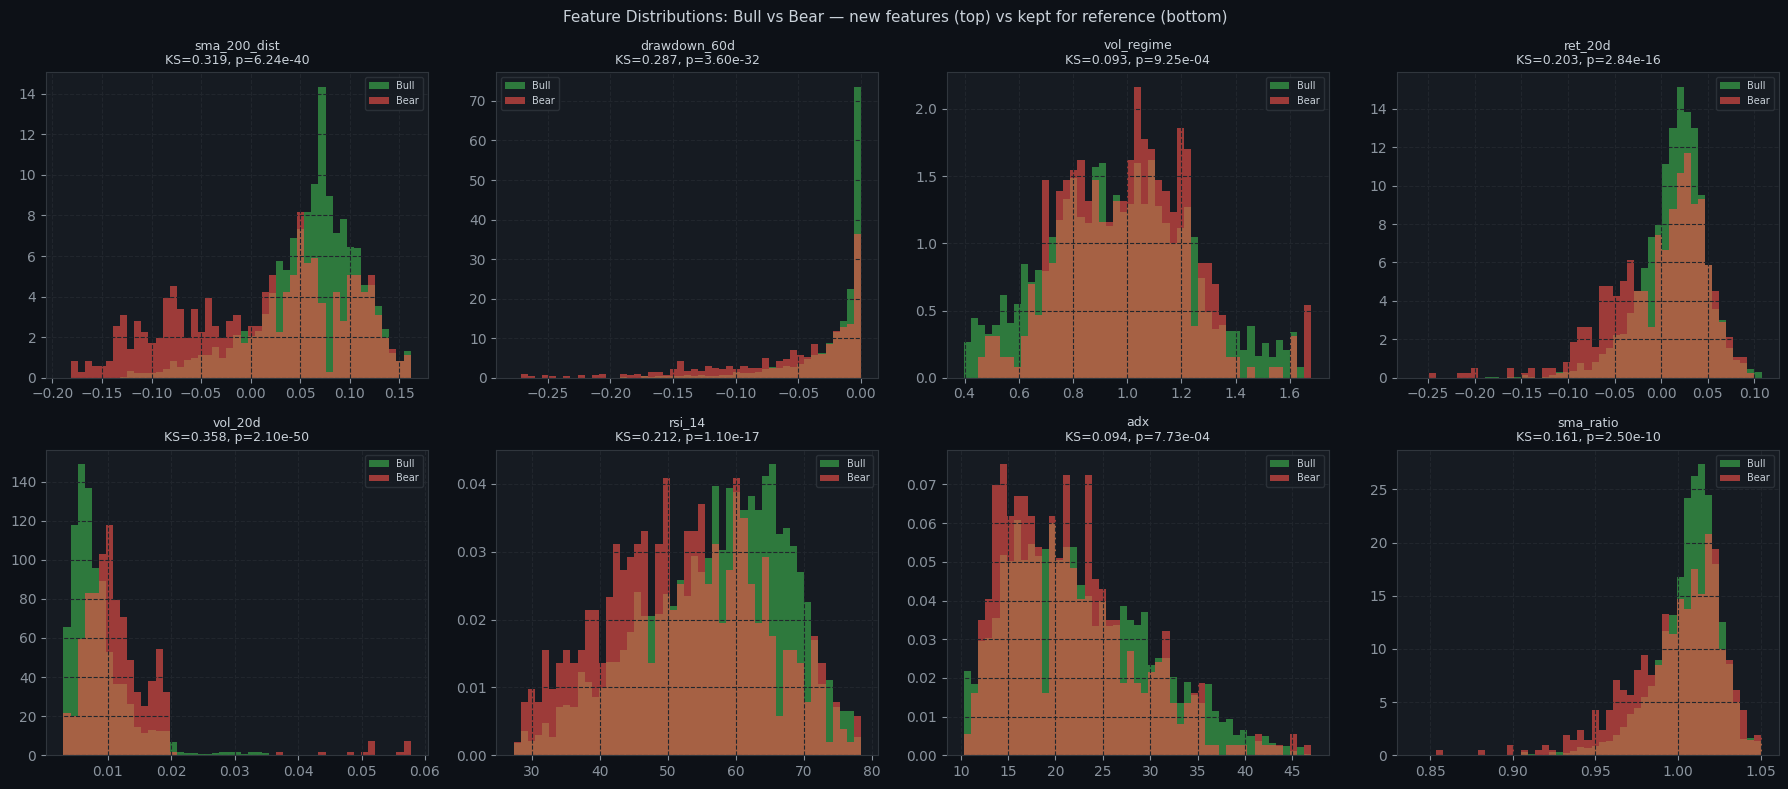

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

bull = df[df['regime'] == 'bull']
bear = df[df['regime'] == 'bear']

for i, feat in enumerate(NEW_FEATURES + ['vol_20d', 'rsi_14', 'adx', 'sma_ratio']):
    ax = axes[i // 4][i % 4]
    b_data  = bull[feat].dropna()
    br_data = bear[feat].dropna()
    
    lo = min(b_data.quantile(0.01), br_data.quantile(0.01))
    hi = max(b_data.quantile(0.99), br_data.quantile(0.99))
    bins = np.linspace(lo, hi, 50)
    
    ax.hist(b_data,  bins=bins, density=True, alpha=0.6, color='#3fb950', label='Bull')
    ax.hist(br_data, bins=bins, density=True, alpha=0.6, color='#f85149', label='Bear')
    
    # KS test: do the distributions differ?
    ks_stat, ks_p = stats.ks_2samp(b_data, br_data)
    ax.set_title(f'{feat}\nKS={ks_stat:.3f}, p={ks_p:.2e}', fontsize=9)
    ax.legend(fontsize=7); ax.grid(True)

plt.suptitle('Feature Distributions: Bull vs Bear — new features (top) vs kept for reference (bottom)',
             fontsize=11)
plt.tight_layout(); plt.show()

## 5 — Rank-IC by Regime

**Rank Information Coefficient** = Spearman correlation between feature rank and next-day return rank.  
- Unconditional IC tells you the overall signal.
- IC conditional on regime tells you *where* a feature actually works.

This is the core question for the policy: does a feature predict tomorrow's return specifically during bear markets?

In [6]:
def rank_ic(series, target):
    """Spearman rank correlation between feature and next-day return."""
    valid = series.notna() & target.notna()
    if valid.sum() < 30:
        return np.nan, np.nan
    r, p = stats.spearmanr(series[valid], target[valid])
    return r, p

rows = []
for feat in ALL_FEATURES:
    ic_all,  p_all  = rank_ic(df[feat],             df['ret_next'])
    ic_bull, p_bull = rank_ic(bull[feat],            bull['ret_next'])
    ic_bear, p_bear = rank_ic(bear[feat],            bear['ret_next'])
    rows.append({
        'feature':   feat,
        'IC_all':    round(ic_all,  4),
        'IC_bull':   round(ic_bull, 4),
        'IC_bear':   round(ic_bear, 4),
        'p_bear':    round(p_bear,  4),
        'group':     'drop' if feat in DROP_FEATURES else ('new' if feat in NEW_FEATURES else 'keep'),
    })

ic_df = pd.DataFrame(rows).sort_values('IC_bear', key=abs, ascending=False)
print('=== Rank-IC vs Next-Day Return by Regime ===')
print(ic_df.to_string(index=False))

=== Rank-IC vs Next-Day Return by Regime ===
     feature  IC_all  IC_bull  IC_bear  p_bear group
      ret_5d -0.0511  -0.0471  -0.0675  0.1309  keep
 adx_di_diff -0.0623  -0.0650  -0.0578  0.1961  keep
      rsi_14 -0.0702  -0.0776  -0.0486  0.2773  keep
      ret_1d -0.0325  -0.0328  -0.0479  0.2842  keep
drawdown_60d -0.0675  -0.0762  -0.0465  0.2989   new
sma_200_dist -0.0427  -0.0491  -0.0360  0.4204   new
   sma_ratio -0.0500  -0.0550  -0.0352  0.4313  keep
         adx  0.0165   0.0152   0.0213  0.6347  keep
  vol_regime  0.0176   0.0240  -0.0177  0.6928   new
     ret_20d -0.0376  -0.0437  -0.0148  0.7410   new
   macd_hist -0.0352  -0.0402  -0.0121  0.7871  drop
    bb_width  0.0261   0.0350  -0.0097  0.8289  drop
   vol_ratio  0.0350   0.0427  -0.0094  0.8339  keep
     obv_ret -0.0195  -0.0232   0.0049  0.9136  keep
     vol_20d  0.0441   0.0560  -0.0009  0.9835  keep


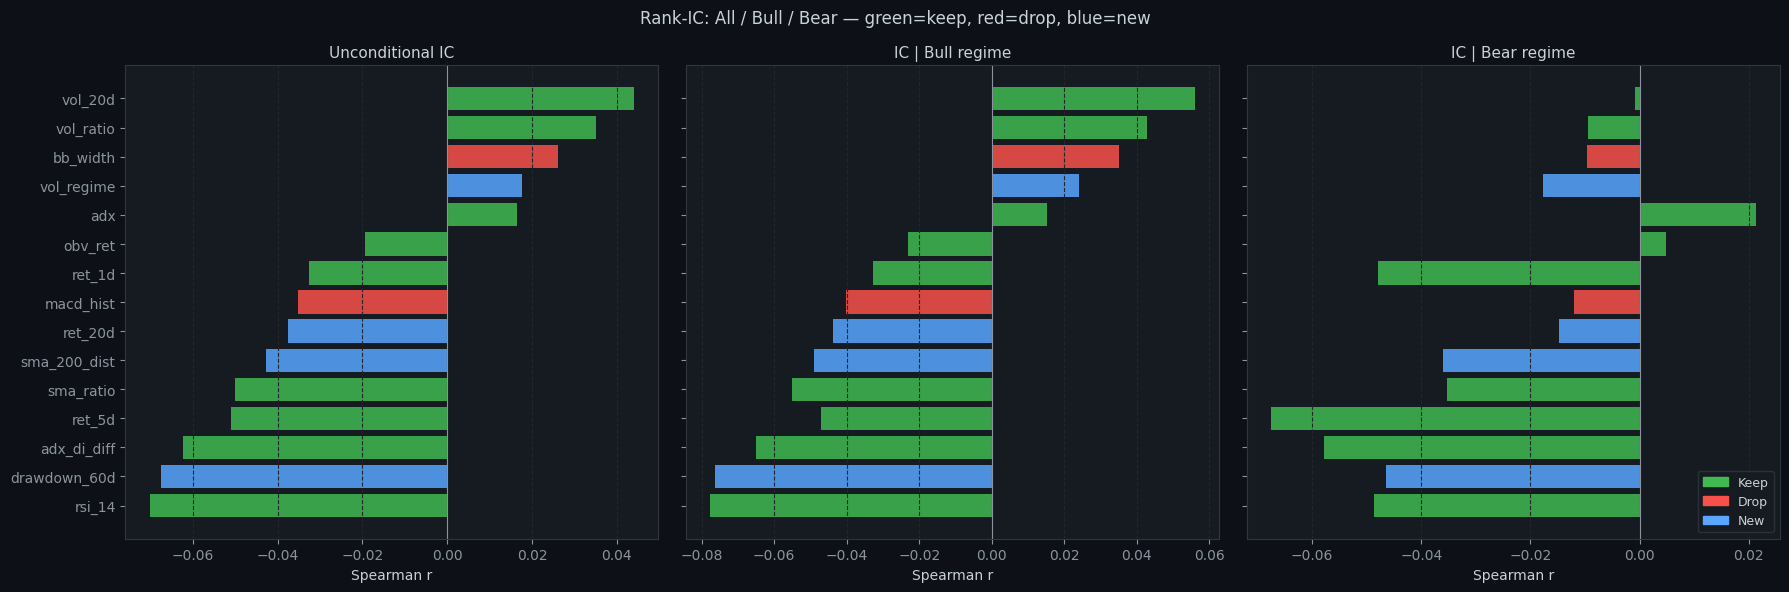

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

group_colors = {'keep': '#3fb950', 'drop': '#f85149', 'new': '#58a6ff'}
titles = [('IC_all', 'Unconditional IC'), ('IC_bull', 'IC | Bull regime'), ('IC_bear', 'IC | Bear regime')]

for ax, (col, title) in zip(axes, titles):
    sorted_df = ic_df.sort_values(col)
    colors = [group_colors[g] for g in sorted_df['group']]
    bars = ax.barh(sorted_df['feature'], sorted_df[col], color=colors, alpha=0.85)
    ax.axvline(0, color='#8b949e', lw=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Spearman r'); ax.grid(axis='x')

legend_patches = [
    mpatches.Patch(color='#3fb950', label='Keep'),
    mpatches.Patch(color='#f85149', label='Drop'),
    mpatches.Patch(color='#58a6ff', label='New'),
]
axes[2].legend(handles=legend_patches, fontsize=9, loc='lower right')

plt.suptitle('Rank-IC: All / Bull / Bear — green=keep, red=drop, blue=new', fontsize=12)
plt.tight_layout(); plt.show()

## 6 — Bear-Day Detection Power (ROC-AUC)

The agent's core job: avoid days when SPY drops > 1%. Which features best predict that?

Binary target: **`drop_day`** = 1 if `ret_next < -0.01`.

In [8]:
from sklearn.metrics import roc_auc_score

df['drop_day'] = (df['ret_next'] < -0.01).astype(int)

print(f'Drop days (ret_next < -1%): {df["drop_day"].sum()} / {len(df)}  ({df["drop_day"].mean()*100:.1f}%)')

rows_auc = []
for feat in ALL_FEATURES:
    valid = df[[feat, 'drop_day']].dropna()
    if len(valid) < 50:
        continue
    # AUC with negative feature (lower feature -> higher drop probability for some features)
    auc_pos = roc_auc_score(valid['drop_day'],  valid[feat])
    auc_neg = roc_auc_score(valid['drop_day'], -valid[feat])
    auc     = max(auc_pos, auc_neg)   # directional
    direction = '+' if auc_pos >= auc_neg else '−'
    rows_auc.append({
        'feature':   feat,
        'AUC':       round(auc, 4),
        'direction': direction,
        'group':     'drop' if feat in DROP_FEATURES else ('new' if feat in NEW_FEATURES else 'keep'),
    })

auc_df = pd.DataFrame(rows_auc).sort_values('AUC', ascending=False)
print('\n=== ROC-AUC for predicting drop day (ret_next < -1%) ===')
print(auc_df.to_string(index=False))

Drop days (ret_next < -1%): 414 / 3823  (10.8%)

=== ROC-AUC for predicting drop day (ret_next < -1%) ===
     feature    AUC direction group
drawdown_60d 0.7058         −   new
      rsi_14 0.6869         −  keep
 adx_di_diff 0.6759         −  keep
     vol_20d 0.6687         +  keep
     ret_20d 0.6543         −   new
   sma_ratio 0.6528         −  keep
sma_200_dist 0.6410         −   new
    bb_width 0.6058         +  drop
   macd_hist 0.6048         −  drop
      ret_5d 0.5967         −  keep
  vol_regime 0.5966         +   new
   vol_ratio 0.5605         +  keep
     obv_ret 0.5432         −  keep
      ret_1d 0.5308         −  keep
         adx 0.5158         +  keep


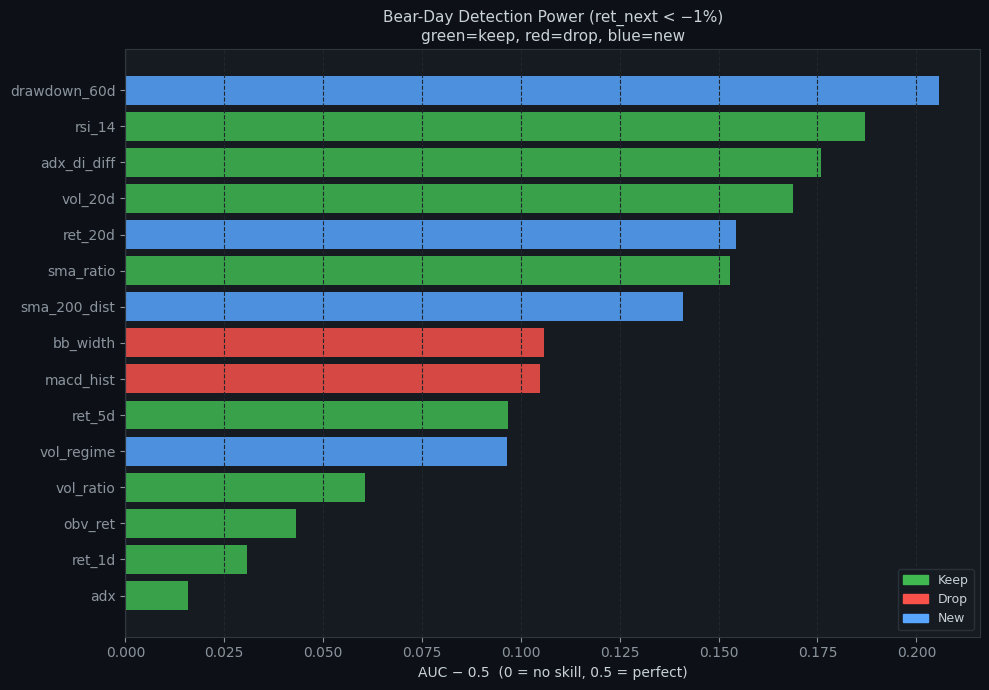

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
sorted_auc = auc_df.sort_values('AUC')
colors = [group_colors[g] for g in sorted_auc['group']]
ax.barh(sorted_auc['feature'], sorted_auc['AUC'] - 0.5, color=colors, alpha=0.85)
ax.axvline(0, color='#8b949e', lw=0.8)
ax.set_xlabel('AUC − 0.5  (0 = no skill, 0.5 = perfect)')
ax.set_title('Bear-Day Detection Power (ret_next < −1%)\ngreen=keep, red=drop, blue=new', fontsize=11)
ax.legend(handles=legend_patches, fontsize=9)
ax.grid(axis='x')
plt.tight_layout(); plt.show()

## 7 — New Feature Timeline with Regime Shading

Visual sanity check: do the new features look like they should during known bear markets?

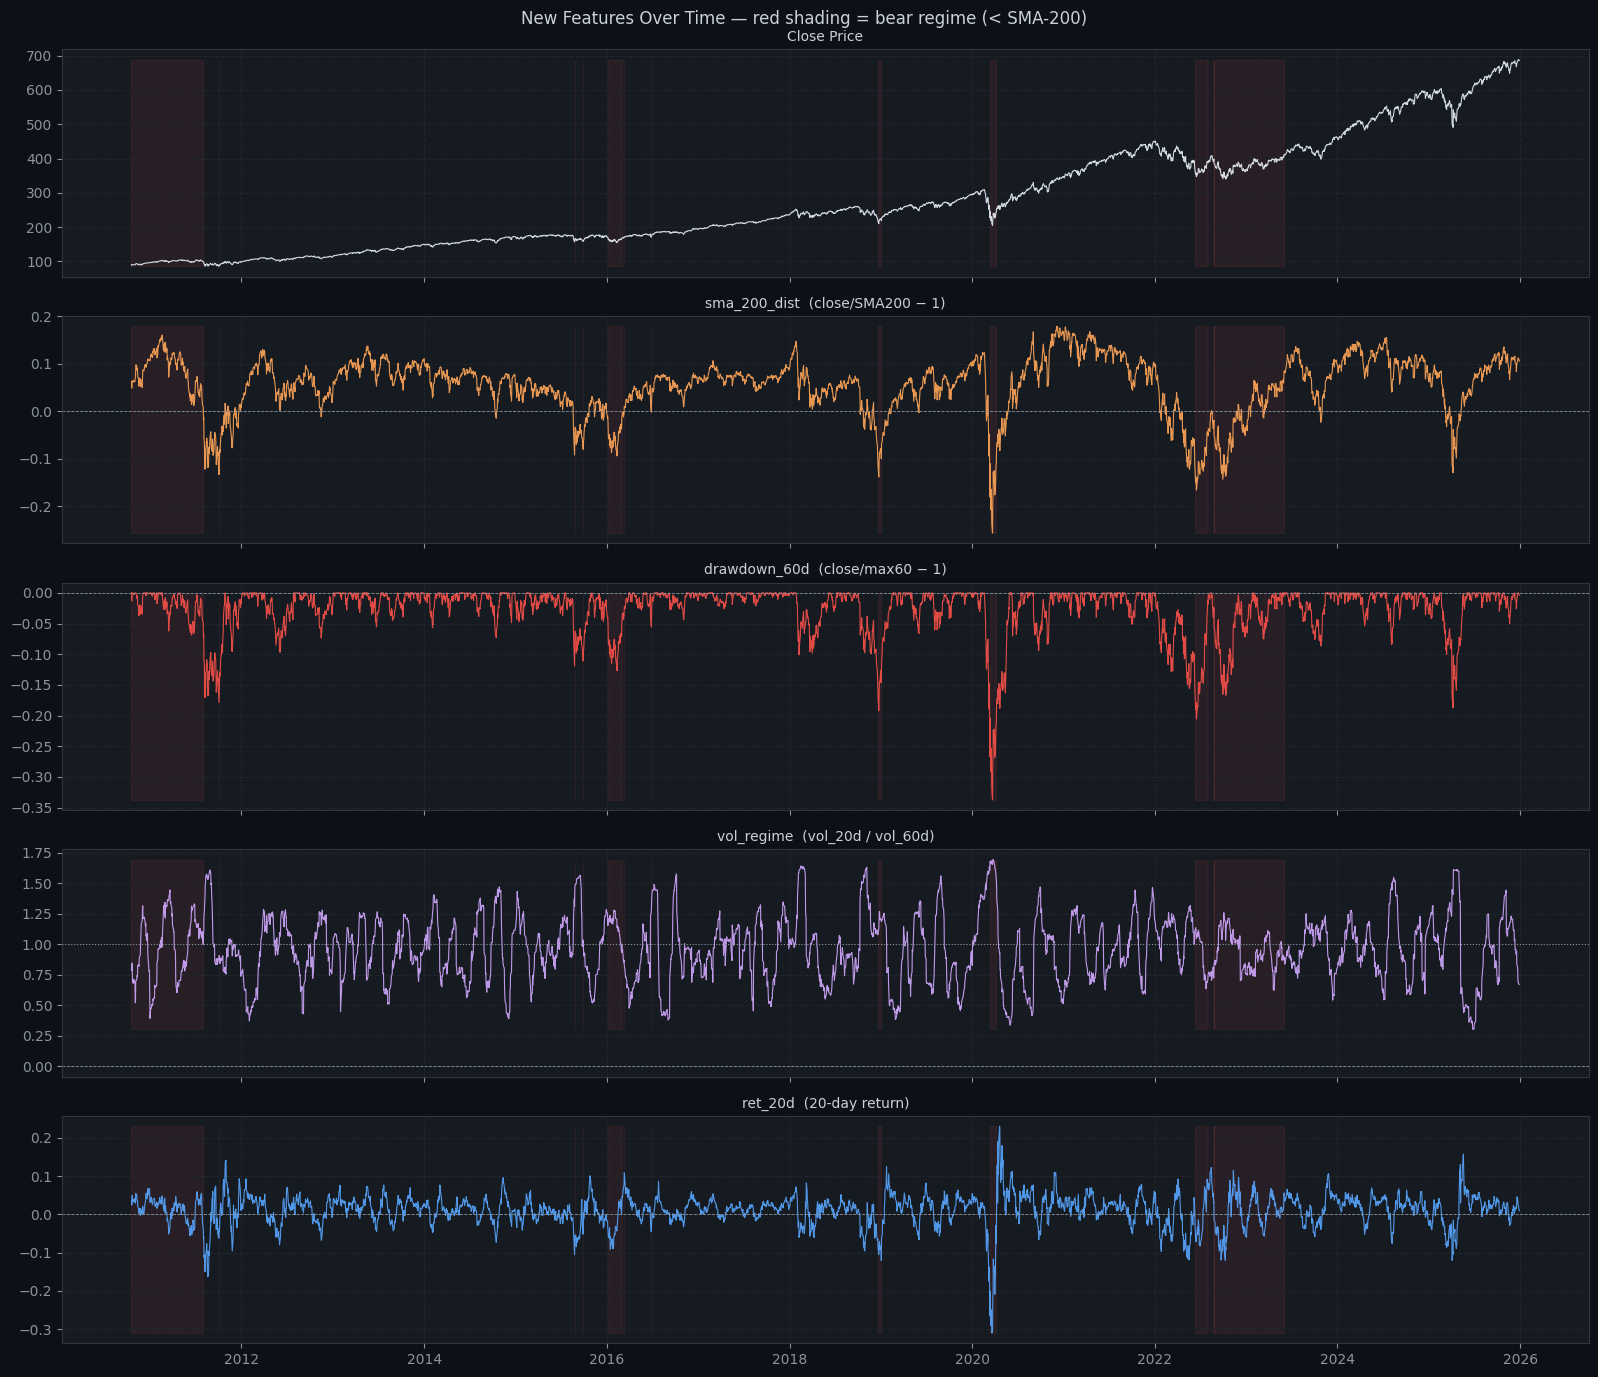

In [10]:
fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)

bear_mask = df['regime'] == 'bear'

panels = [
    ('close',        '#e6edf3', 'Close Price'),
    ('sma_200_dist', '#ffa657', 'sma_200_dist  (close/SMA200 − 1)'),
    ('drawdown_60d', '#f85149', 'drawdown_60d  (close/max60 − 1)'),
    ('vol_regime',   '#d2a8ff', 'vol_regime  (vol_20d / vol_60d)'),
    ('ret_20d',      '#58a6ff', 'ret_20d  (20-day return)'),
]

for ax, (col, color, title) in zip(axes, panels):
    ax.plot(df['date'], df[col], color=color, lw=0.8, alpha=0.9)
    ax.fill_between(df['date'], df[col].min(), df[col].max(),
                    where=bear_mask, color='#f85149', alpha=0.08)
    if col != 'close':
        ax.axhline(0, color='#8b949e', lw=0.6, ls='--')
    if col == 'vol_regime':
        ax.axhline(1, color='#8b949e', lw=0.8, ls=':')
    ax.set_title(title, fontsize=10)
    ax.grid(True)

plt.suptitle('New Features Over Time — red shading = bear regime (< SMA-200)', fontsize=12)
plt.tight_layout(); plt.show()

## 8 — Collinearity Among Final Feature Set

Make sure the 13-feature final set (9 kept + 4 new) doesn't have new collinearity problems introduced by the additions.

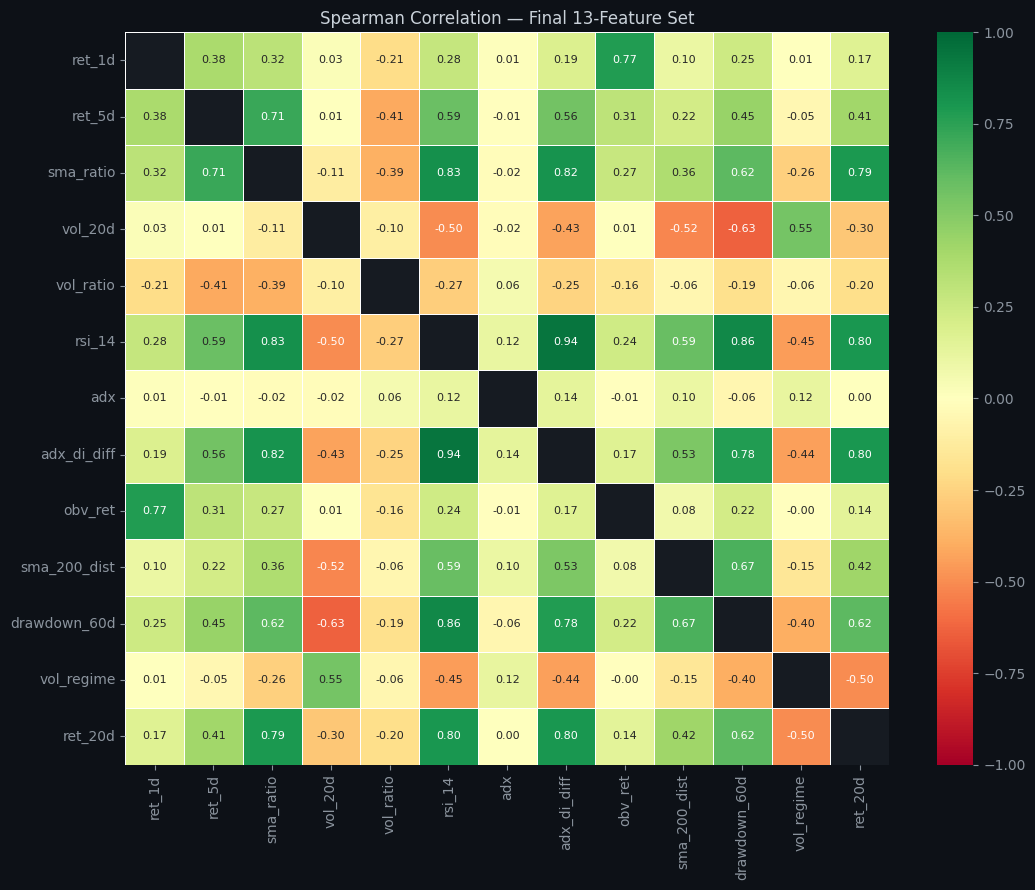

High-correlation pairs (|r| > 0.70):
  rsi_14               vs adx_di_diff           r=0.94
  rsi_14               vs drawdown_60d          r=0.863
  sma_ratio            vs rsi_14                r=0.835
  sma_ratio            vs adx_di_diff           r=0.817
  rsi_14               vs ret_20d               r=0.801
  adx_di_diff          vs ret_20d               r=0.797
  sma_ratio            vs ret_20d               r=0.792
  adx_di_diff          vs drawdown_60d          r=0.781
  ret_1d               vs obv_ret               r=0.775
  ret_5d               vs sma_ratio             r=0.712


In [11]:
import seaborn as sns

final_features = KEEP_FEATURES + NEW_FEATURES
corr = df[final_features].corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.eye(len(final_features), dtype=bool)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 8})
ax.set_title('Spearman Correlation — Final 13-Feature Set', fontsize=12)
plt.tight_layout(); plt.show()

# Flag any pair > 0.7
high_corr = []
for i in range(len(final_features)):
    for j in range(i+1, len(final_features)):
        r = corr.iloc[i, j]
        if abs(r) > 0.70:
            high_corr.append((final_features[i], final_features[j], round(r, 3)))

if high_corr:
    print('High-correlation pairs (|r| > 0.70):')
    for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f'  {a:20s} vs {b:20s}  r={r}')
else:
    print('No pairs with |r| > 0.70 — final feature set looks clean.')

## 9 — IC Rolling Stability

A feature with high mean IC but unstable IC is unreliable — the agent will learn it in train and it'll vanish in test. Check rolling 252-day Spearman IC for the best new features vs the best existing ones.

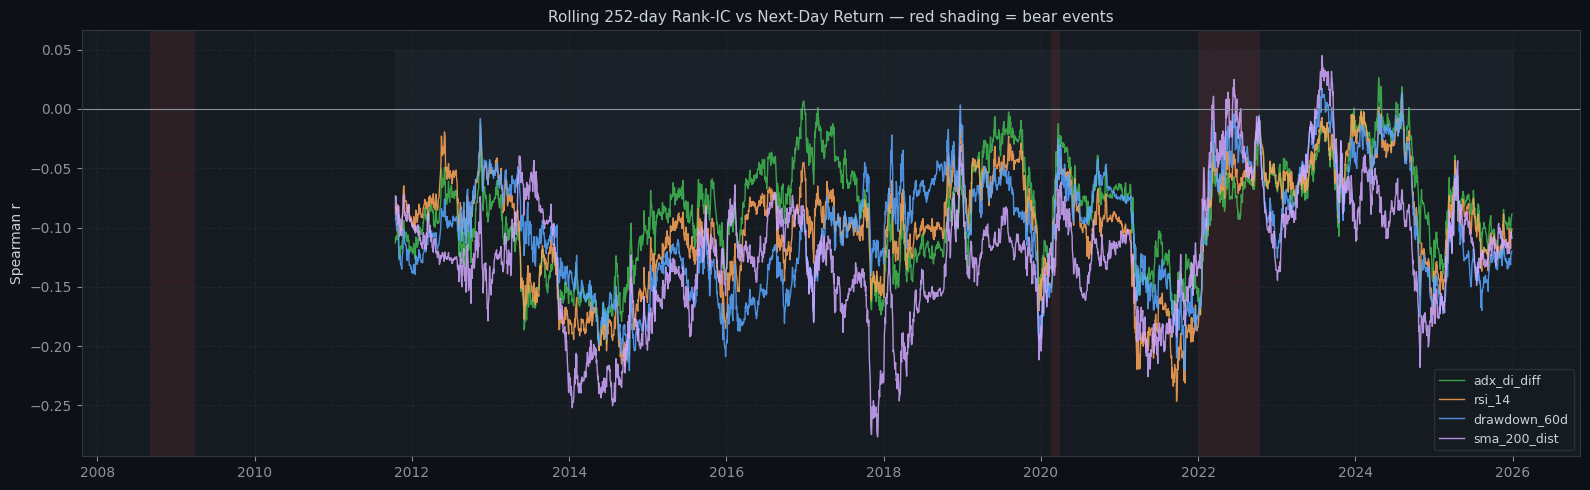

In [12]:
# Pick the 4 most interesting features to compare (2 old, 2 new)
features_to_track = ['adx_di_diff', 'rsi_14', 'drawdown_60d', 'sma_200_dist']
colors_track      = ['#3fb950',     '#ffa657', '#58a6ff',       '#d2a8ff']

window = 252  # 1 trading year

fig, ax = plt.subplots(figsize=(16, 5))

for feat, color in zip(features_to_track, colors_track):
    rolling_ic = []
    for end in range(window, len(df)):
        slice_  = df.iloc[end-window:end]
        valid   = slice_[[feat, 'ret_next']].dropna()
        if len(valid) < 50:
            rolling_ic.append(np.nan)
        else:
            r, _ = stats.spearmanr(valid[feat], valid['ret_next'])
            rolling_ic.append(r)
    
    dates_roll = df['date'].iloc[window:].values
    ax.plot(dates_roll, rolling_ic, color=color, lw=1.0, label=feat, alpha=0.85)

ax.axhline(0, color='#8b949e', lw=0.8)
ax.fill_between(df['date'].iloc[window:], -0.05, 0.05, alpha=0.05, color='#8b949e')

# Shade known bear periods
for start, end, label in bear_periods:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color='#f85149', alpha=0.10, lw=0)

ax.set_title('Rolling 252-day Rank-IC vs Next-Day Return — red shading = bear events', fontsize=11)
ax.set_ylabel('Spearman r')
ax.legend(fontsize=9); ax.grid(True)
plt.tight_layout(); plt.show()

## 10 — Summary: Decision Table

In [13]:
summary = ic_df.merge(auc_df[['feature','AUC','direction']], on='feature')
summary['decision'] = summary['group'].map({'keep':'KEEP','drop':'DROP','new':'ADD'})

print('=== Final Feature Decision Table ===')
print(summary[['feature','group','IC_all','IC_bull','IC_bear','AUC','direction','decision']]
      .sort_values(['decision','IC_bear'], key=lambda x: x if x.name!='decision' else x.map({'KEEP':0,'ADD':1,'DROP':2}))
      .to_string(index=False))

print('\n--- Final 13-feature observation vector ---')
for i, f in enumerate(final_features, 1):
    tag = '[NEW]' if f in NEW_FEATURES else '     '
    print(f'  {i:2d}. {tag} {f}')
print('  14.       position       (env-injected)')
print('  15.       equity_return  (env-injected)')

=== Final Feature Decision Table ===
     feature group  IC_all  IC_bull  IC_bear    AUC direction decision
      ret_5d  keep -0.0511  -0.0471  -0.0675 0.5967         −     KEEP
 adx_di_diff  keep -0.0623  -0.0650  -0.0578 0.6759         −     KEEP
      rsi_14  keep -0.0702  -0.0776  -0.0486 0.6869         −     KEEP
      ret_1d  keep -0.0325  -0.0328  -0.0479 0.5308         −     KEEP
   sma_ratio  keep -0.0500  -0.0550  -0.0352 0.6528         −     KEEP
   vol_ratio  keep  0.0350   0.0427  -0.0094 0.5605         +     KEEP
     vol_20d  keep  0.0441   0.0560  -0.0009 0.6687         +     KEEP
     obv_ret  keep -0.0195  -0.0232   0.0049 0.5432         −     KEEP
         adx  keep  0.0165   0.0152   0.0213 0.5158         +     KEEP
drawdown_60d   new -0.0675  -0.0762  -0.0465 0.7058         −      ADD
sma_200_dist   new -0.0427  -0.0491  -0.0360 0.6410         −      ADD
  vol_regime   new  0.0176   0.0240  -0.0177 0.5966         +      ADD
     ret_20d   new -0.0376  -0.0437  -0.